# Data Validation & Data Quality Checks

This lecture covers:
- **Data Validation:** Checking data types, missing values, and basic consistency.
- **Outlier Detection:** Using boxplots and the IQR method.
- **Identifying Inconsistencies & Errors:** Spotting duplicates and unexpected values.

In [1]:
import pandas as pd  # For data manipulation
import numpy as np  # For numerical operations
import seaborn as sns  # For easy dataset loading and visualizations
import matplotlib.pyplot as plt  # For plotting
from scipy.stats import iqr  # For getting the iqr

## Load the Dataset

We'll use the **tips** dataset from seaborn, with an appended row containing negative values to simulate errors.

In [2]:
df = sns.load_dataset("tips")
# Appending a negative tip
df.loc[-1] = [-25, -5, "Male", "Yes", "Jan", "Midnight", 30]

## 1. Data Validation

### Data Overview

First few rows of the dataset:

In [9]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Data Types & Missing Values

Data Types:

In [8]:
df.dtypes

total_bill    float64
tip           float64
sex            object
smoker         object
day            object
time           object
size            int64
dtype: object

Missing Values per Column:

In [7]:
df.isnull()

,total_bill,tip,sex,smoker,day,time,size
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
240,False,False,False,False,False,False,False
241,False,False,False,False,False,False,False
242,False,False,False,False,False,False,False
243,False,False,False,False,False,False,False


## 2. Detecting Outliers

### Boxplot for Selected Column

Change the `column` variable below to explore different numeric columns (e.g., `"total_bill"`, `"tip"`, `"size"`).

<Axes: xlabel='total_bill'>

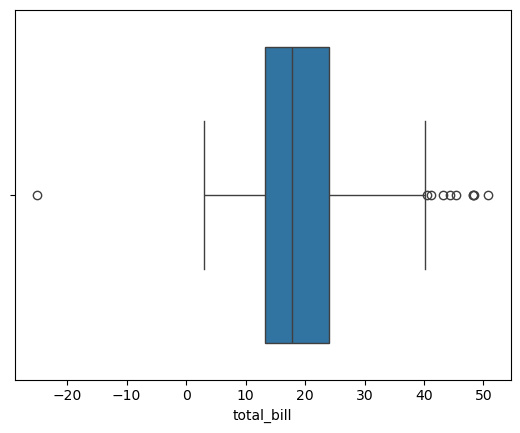

In [11]:
column = "total_bill"

sns.boxplot(x = df[column])

### IQR Method for Outlier Detection

Calculate the IQR to identify outliers:

In [17]:
# Compute Q1 and Q3 using numpy

Q1, Q3 = np.percentile(df[column], [25,75])
IQR = iqr(df[column])

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound)
print(upper_bound)

# Identify outliers
df[(df[column] < lower_bound) | (df[column] > upper_bound)]

-2.92
40.28


,total_bill,tip,sex,smoker,day,time,size
59,48.27,6.73,Male,No,Sat,Dinner,4
102,44.30,2.50,Female,Yes,Sat,Dinner,3
142,41.19,5.00,Male,No,Thur,Lunch,5
156,48.17,5.00,Male,No,Sun,Dinner,6
170,50.81,10.00,Male,Yes,Sat,Dinner,3
182,45.35,3.50,Male,Yes,Sun,Dinner,3
184,40.55,3.00,Male,Yes,Sun,Dinner,2
197,43.11,5.00,Female,Yes,Thur,Lunch,4
212,48.33,9.00,Male,No,Sat,Dinner,4
-1,-25.00,-5.00,Male,Yes,Jan,Midnight,30


In [20]:
df["time"].value_counts()

time
Dinner      176
Lunch        68
Midnight      1
Name: count, dtype: int64

## 3. Identifying Inconsistencies and Errors

### Duplicate Records

In [21]:
# Check for duplicate rows in the dataset
df[df.duplicated() == 1]

,total_bill,tip,sex,smoker,day,time,size
202,13.0,2.0,Female,Yes,Thur,Lunch,2


### Checking for Unexpected Values in 'tip'

A negative tip value would be an error — let's check for those.

In [23]:
# Check for negative tip values
df[df["tip"] < 0]

,total_bill,tip,sex,smoker,day,time,size
-1,-25.0,-5.0,Male,Yes,Jan,Midnight,30


## Conclusion

Validating your data is a crucial first step in any analysis.  
By checking for data type mismatches, missing values, outliers, duplicates,  
and other inconsistencies, you can ensure that your insights are based on reliable data.